# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Sophie Leszek
* Username: zeleszek
* Student number: s5686709
* Group (AS1, etc.): AS5

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

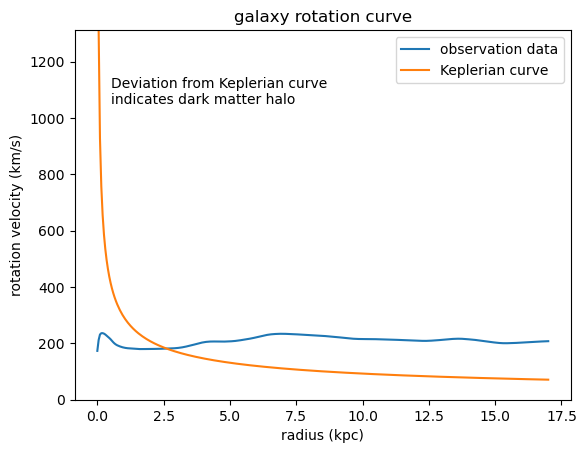

In [18]:
import numpy as np
from matplotlib.pyplot import figure, show

data = np.loadtxt('rotcur.dat')
R = data[:,0] #kpc
V = data[:,1] #km/s

#calculating the Kaplerian:
G = 4.302e-6  # kpc (km/s)^2 / Msun
M = 2e10      # solar masses

#using mask for instances where R can be iffy like 0 and create infinite V
mask = (R > 0)
R2 = R[mask] 
V_kep = np.sqrt(G * M / R2)
#saving the kaplerian:
np.savetxt("keplerian_curve.txt", np.column_stack((R2, V_kep)))

data2 = np.loadtxt("keplerian_curve.txt")
R2 = data2[:,0] 
V2 = data2[:,1] 


fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(R, V, label="observation data")
frame.plot(R2, V2, label="Keplerian curve")
frame.set_title('galaxy rotation curve')
frame.set_xlabel('radius (kpc)')
frame.set_ylabel('rotation velocity (km/s)')
frame.legend()
frame.set_ylim(0, np.max(V_kep))
frame.text(
    0.5, np.max(V_kep)*0.8,
    "Deviation from Keplerian curve\nindicates dark matter halo",
    fontsize=10
)
show()

#The theoretical curve would be a Keplerian rotation curve. So what is special to the plotted curve?
# Because it shows that somehow the mass in a galaxy must increase with radius, which is bc of dark matter

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

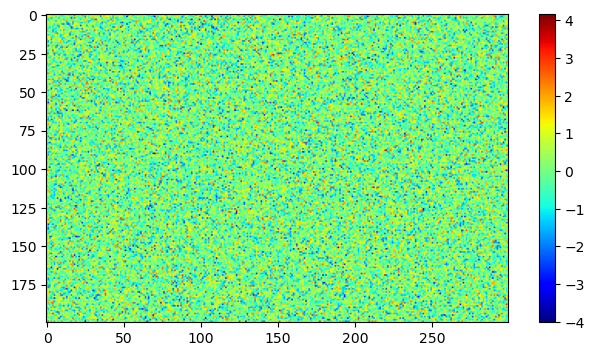

the mean = -0.014263498366821429, the standard deviation = 1.0325326001587782
the mean and std are close enough to the one given for the figure, so the values were expected


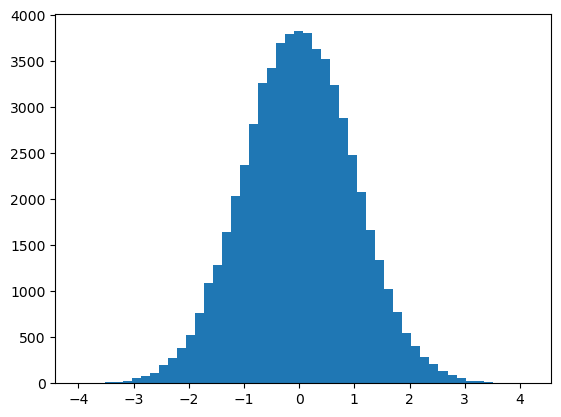

resembles the gaussian distribution


In [19]:
import numpy as np
from matplotlib import pyplot as plt

M = np.random.normal(loc=0.0, scale=1.0, size = 200*300).reshape(200,300)

fig = plt.figure(figsize=(8, 4)) 
ax = fig.add_subplot(1, 1, 1) 
image = ax.imshow(M, cmap='jet')
fig.colorbar(image, ax=ax)
plt.show()

slice = M[100:130, 150:180] #took 30x30 slice in the middle, roughly
mean = np.mean(slice)
std = np.std(slice)

print(f"the mean = {mean}, the standard deviation = {std}")
print(f"the mean and std are close enough to the one given for the figure, so the values were expected")

fig = plt.figure()
frame = fig.add_subplot(1,1,1)
frame.hist(M.ravel(), bins=50)
plt.show()
print(f"resembles the gaussian distribution")

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

18.84955592153876 15.865437575563961
center: (1, 1), semi-major axis: 3, semi-minor axis: 2, position angle: 0


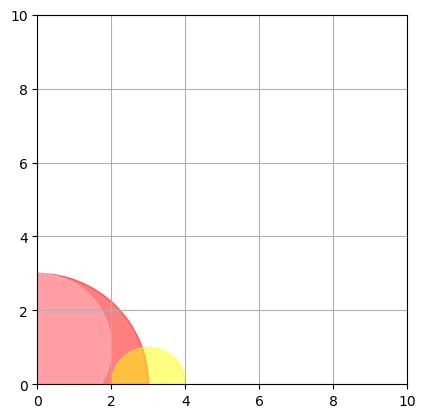

In [21]:
from matplotlib.patches import Ellipse
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt

import numpy as np
from numpy import pi, sqrt

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      self.semi_major = semi_major
      self.semi_minor = semi_minor
      self.xc = xc
      self.yc = yc
      self.position_angle = position_angle
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(XY, width, height, angle=angle_mpl, **args)
    def area(self):
        a = self.semi_major
        b = self.semi_minor
        area = pi * a * b   #area = pi*a*b from task4
        return area
    def perimeter(self):     #p = (3*(a+b) - sqrt((a+3*b)*(3*a+b)))*pi from task 4, semi-minor is b
        a = self.semi_major
        b = self.semi_minor
        perimeter = pi*(3*(a + b) - sqrt((a + 3*b)*(3*a + b)))
        return perimeter
    def _str_(self):
        s = f"center: ({self.xc}, {self.yc}), semi-major axis: {self.semi_major}, semi-minor axis: {self.semi_minor}, position angle: {self.position_angle}"
        return s

ellipse = AstroEllipse(1, 1, 3, 2, 0)
a = ellipse.area()
p = ellipse.perimeter()
print(a, p)
s = ellipse._str_()
print(s)

class MyCircle(AstroEllipse):
    def __init__(self, x, y, radius, **args):
        xc = x
        yc = y
        semi_major = radius
        semi_minor = radius
        position_angle = 0
        super().__init__(xc, yc, semi_major, semi_minor, position_angle, **args)

x = np.random.randint(0, 5, 3)
y = np.random.randint(0, 5, 3)
r = np.random.randint(1, 5, 3)

c1 = MyCircle(x[0], y[0], r[0], color = 'red', alpha=0.5)
c2 = MyCircle(x[1], y[1], r[1],color = 'pink', alpha=0.5)
c3 = MyCircle(x[2], y[2], r[2], color = 'yellow', alpha=0.5)


fig = figure()
frame = fig.add_subplot(1,1,1, aspect=1)

frame.add_patch(c1)
frame.add_patch(c2)
frame.add_patch(c3)
frame.grid()
frame.set_xlim(0,10)
frame.set_ylim(0,10)
show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

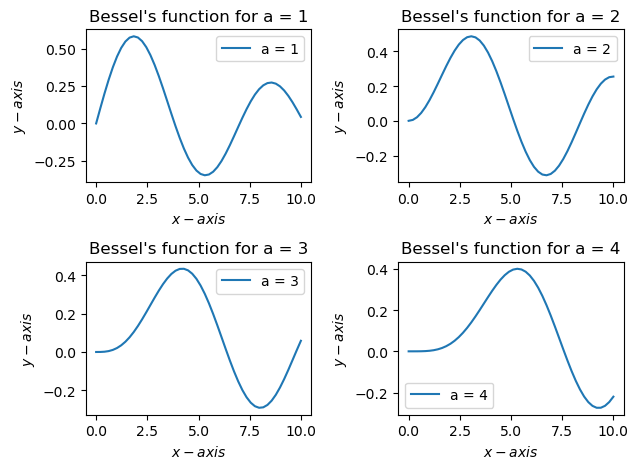

In [22]:
from scipy.special import jv
from matplotlib.pyplot import figure, show
import numpy as np

x = np.linspace(0, 10)

fig = figure()
for i in range(4):
    frame = fig.add_subplot(2, 2, i+1)
    y = jv(i+1, x)
    frame.plot(x, y, label=f"a = {i+1}")
    frame.set_xlabel("$x-axis$")
    frame.set_ylabel("$y-axis$")
    frame.legend()
    frame.set_title(f"Bessel's function for a = {i+1}")
fig.tight_layout()
show()

fig.savefig("bessel.png", orientation='landscape',
            transparent=True)

Markdown:

![bessel](bessel.png)

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

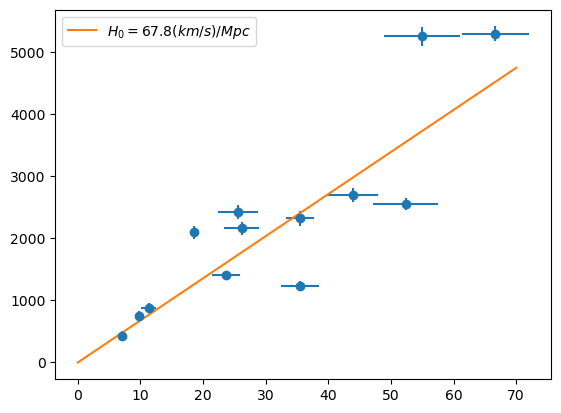

In [23]:
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]
d = data[0::4]
v = data[1::4]
e_d = data[2::4]
e_v = data[3::4]

fig = figure()
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(d, v, xerr = e_d, yerr = e_v, fmt='o')
ax.plot([0, 70], [0, 70*67.8], label = "$H_0 = 67.8(km/s)/Mpc$")
ax.legend()
show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")